# Full-dataset embeddings

Same pipeline as `learnathon/02_Learnathon_Embeddings.ipynb`, same scripts
(`scripts/learnathon_embed_{metabolites,proteins,genes}.py`), but pointed at
the **full graph** (`data/processed/`) instead of the 2-species Learnathon
subset (`data/processed/learnathon/`). See `learnathon/LEARNATHON_EMBEDDINGS.md`
for the detailed per-stage resolver/embedding documentation — that doc still
applies; only the paths below change.

| Node type | # nodes (full graph, `plantcyc17.0.0-gpml2021-v3.1`) | # nodes (Learnathon subset) | Source identifiers | Embedding |
|---|---:|---:|---|---|
| `Metabolite` | 4,577 | 1,417 | InChIKey / ChEBI / MetaNetX / PubChem / KEGG / HMDB | SMILES → MAP4 fingerprint |
| `Protein` | 3,750 | 1,487 | UniProt / TAIR / PlantCyc / PDB / RefSeq | sequence → ESM (`esmc`) |
| `GeneProduct` | 2,741 | 1,224 | GenBank / TAIR / PlantCyc / UniProt / STRING / Phytozome / BioCyc / Ensembl | DNA sequence → PlantCaduceus |

**What's actually different at full scale (read this before running anything):**

1. **421 distinct species, not 2.** The Learnathon subset only ever needed to
   resolve identifiers for *A. thaliana* and *G. max* — the resolvers were
   validated against exactly those two genomes' worth of NCBI/UniProt
   records. The full graph spans 421 organisms (`data/processed/edges.tsv`
   `organism` edges), most far less densely annotated in public databases.
   **Expect lower resolution rates than the subset's ~85-89%, and expect
   them to vary a lot by species** — there's no way to know in advance
   without running the diagnostics below.
2. **`extract_locus`'s regex (`LOCUS_RE`) only recognises Arabidopsis
   (`AT#G#####`) and soybean (`Glyma.##G######`) locus-tag formats.** For
   `tair.name`/`plantcyc`-namespace nodes whose identifier doesn't contain
   one of those substrings, the raw identifier is passed through unchanged
   and searched against UniProt as a gene name, which (correctly) finds
   nothing. Confirmed in §4.3: this fails for ~all non-Arabidopsis
   `plantcyc` proteins (0/1,591) *and* for most Arabidopsis `plantcyc`
   proteins too (33/42), since many PlantCyc IDs use a gene symbol or a
   generic numeric accession rather than a locus tag. Extending the regex
   per-species is future work if needed.
3. **Logging**: every resolve/embed run (whether via this notebook or the
   CLI commands in §3.2/4.2/5.2) appends a line to
   `data/interim/full_embeddings/embedding_log.jsonl` — `{node_type, stage,
   total, resolved|embedded, timestamp_utc}`. §6 reads this file back so you
   always have a persistent record of "how many resolved" / "how many
   embedded", independent of which terminal or notebook kernel produced it.

**Prerequisite**: `data/processed/{nodes.tsv,edges.tsv,heterodata.pt}` need
to exist (see `README.md` "Building the PyG" for how to (re)build them from
a fresh Zenodo download). The setup cell below checks for them.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

FULL_DIR = ROOT / "data" / "processed"
CACHE_DIR = ROOT / "data" / "interim" / "full_embeddings"
INTERIM_DIR = ROOT / "data" / "interim"
LOG_PATH = CACHE_DIR / "embedding_log.jsonl"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT / "scripts"))
import learnathon_embed_common as common
import learnathon_embed_metabolites as embed_metabolites
import learnathon_embed_proteins as embed_proteins
import learnathon_embed_genes as embed_genes

_required = [FULL_DIR / "nodes.tsv", FULL_DIR / "edges.tsv", FULL_DIR / "heterodata.pt"]
_missing = [p for p in _required if not p.exists()]
for p in _required:
    print(f"  {p}: {'OK' if p.exists() else 'MISSING'}")
if _missing:
    print()
    print("Rebuild the full graph first (see the markdown cell below for why), then re-run this cell:")
    print()
    print("  python scripts/fetch_zenodo.py")
    print("  python scripts/unpack_ttl.py")
    print("  python scripts/inspect_rdf.py --top 25")
    print("  python scripts/rdf_to_typed_tables.py")
    print("  python scripts/build_pyg.py")


  /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/nodes.tsv: OK
  /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/edges.tsv: OK
  /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/heterodata.pt: OK


## 1. Node-id namespace inventory (full graph)

In [2]:
nodes = pd.read_csv(FULL_DIR / "nodes.tsv", sep="\t")

for node_type in ["Metabolite", "Protein", "GeneProduct"]:
    ids = nodes.loc[nodes["node_type"] == node_type, "node_id"]
    counts = Counter(common.namespace(n) for n in ids)
    print(f"{node_type} ({len(ids)} nodes):")
    for ns, n in counts.most_common():
        print(f"    {ns:<20} {n}")
    print()


Metabolite (17476 nodes):
    DataNode             12899
    inchikey             4111
    chebi                174
    MetaNetX             172
    pubchem.compound     75
    kegg.compound        43
    hmdb                 2

Protein (13682 nodes):
    DataNode             9932
    uniprot              1797
    plantcyc             1633
    tair.name            316
    refseq               3
    pdb                  1

GeneProduct (6480 nodes):
    DataNode             3739
    plantcyc             1369
    tair.name            939
    ncbigene             361
    string               37
    Phytozome            19
    biocyc               10
    uniprot              3
    refseq               2
    ensembl              1



## 2. Organism coverage

Every Metabolite/Protein/GeneProduct node has a direct `organism` edge
(100% coverage, confirmed below) -- `load_organism_map` resolves these
directly; it also has a defensive fallback (via `Protein/GeneProduct
-is_part_of-> Pathway -organism-> Organism`) for the case where direct tags
are unavailable, though that path isn't needed for the current data.

421 distinct taxa. One data-quality wrinkle to know about: NCBI taxon
`33090` ("Viridiplantae" -- green plants in general, not a real species) is
by far the most common `organism` edge target (28,420 / 53,561
organism-tagged nodes -- 53%), because the upstream taxonomy-extra
annotations themselves don't pin those nodes to anything more specific.
Nodes tagged with it have no real species to resolve a sequence against --
expect those to mostly fail to resolve, not silently resolve wrong.

In [3]:
organism_map = common.load_organism_map(FULL_DIR)

for node_type in ["Protein", "GeneProduct"]:
    ids = nodes.loc[nodes["node_type"] == node_type, "node_id"]
    with_organism = sum(n in organism_map for n in ids)
    print(f"{node_type}: {with_organism}/{len(ids)} have an organism edge")

taxon_counts = Counter(organism_map.values())
print(f"\n{len(taxon_counts)} distinct taxa across Protein+GeneProduct organism edges")
print("Top 10 by node count:")
for taxon, n in taxon_counts.most_common(10):
    flag = "  <- generic 'Viridiplantae', not a real species" if taxon == "33090" else ""
    print(f"  taxid:{taxon:<10} {n:>5}{flag}")


Protein: 13682/13682 have an organism edge
GeneProduct: 6480/6480 have an organism edge

421 distinct taxa across Protein+GeneProduct organism edges
Top 10 by node count:
  taxid:33090      28380  <- generic 'Viridiplantae', not a real species
  taxid:3702        7552
  taxid:3847        1358
  taxid:34305       1156
  taxid:3055         776
  taxid:381124       694
  taxid:4081         583
  taxid:4113         475
  taxid:3888         308
  taxid:4530         286


## 3. Metabolite resolution (full set — graph-native steps aren't rate-limited, so run all 4,576 directly)

In [4]:
# Rebuilds the properties_extra_xrefs cache fresh against the new TTLs
# (the old one was deliberately NOT carried over from the Learnathon cache --
# it's a parse of reactions.ttl/properties_extra.ttl, which the rebuild above
# just replaced with a newer release; reusing the old parse would silently
# serve stale graph-native SMILES/xref data).
xrefs = common.load_properties_extra_xrefs(INTERIM_DIR, CACHE_DIR)
print(f"properties_extra_xrefs.json: {len(xrefs):,} identifiers.org URIs with graph-native properties")

metabolite_ids = common.load_nodes(FULL_DIR, "Metabolite")
metabolite_by_namespace = {}
for node_id in metabolite_ids:
    metabolite_by_namespace.setdefault(common.namespace(node_id), []).append(node_id)

print(f"\nMetabolite namespace x property coverage ({len(metabolite_ids)} total):")
print(f"  {'namespace':<20} {'total':>6}  {'Smiles':>8}  {'AltPubchem':>10}  {'AltMnx':>8}  {'NoStruct':>8}")
for ns, ids in metabolite_by_namespace.items():
    has_smiles  = sum(bool(xrefs.get(n, {}).get("Smiles")) for n in ids)
    has_pubchem = sum(bool(xrefs.get(n, {}).get("AlternativeId_Pubchem")) for n in ids)
    has_mnx     = sum(bool(xrefs.get(n, {}).get("AlternativeId_Metanetx")) for n in ids)
    no_struct   = sum(xrefs.get(n, {}).get("HasNoStructure?") == "T" for n in ids)
    print(f"  {ns:<20} {len(ids):>6}  {has_smiles:>8}  {has_pubchem:>10}  {has_mnx:>8}  {no_struct:>8}")


properties_extra_xrefs.json: 6,248 identifiers.org URIs with graph-native properties



Metabolite namespace x property coverage (17476 total):
  namespace             total    Smiles  AltPubchem    AltMnx  NoStruct
  DataNode              12899         0           0         0         0
  MetaNetX                172       151           0       172        32
  chebi                   174       156           0       154        23
  hmdb                      2         2           0         1         0
  inchikey               4111      4111        4010      3661         0
  kegg.compound            43        39           0        32         6
  pubchem.compound         75        57          75        60         1


In [5]:
# Full resolve -- graph-native steps (1-3) are fast/no network; PubChem/KEGG REST
# fallbacks (steps 4-6) only fire for the minority not covered by properties_extra,
# but with 4,576 nodes (vs. the subset's 1,417) this can still take a few minutes.
smiles = embed_metabolites.resolve_metabolite_smiles(metabolite_ids, CACHE_DIR, interim_dir=INTERIM_DIR)
print(f"resolved SMILES for {len(smiles)}/{len(metabolite_ids)} Metabolite nodes")
common.log_event(LOG_PATH, node_type="Metabolite", stage="resolve",
                  total=len(metabolite_ids), resolved=len(smiles))

print(f"\nPer-namespace resolution rate:")
for ns, ids in metabolite_by_namespace.items():
    n_ok = sum(n in smiles for n in ids)
    print(f"  {ns:<20} {n_ok:>4}/{len(ids):<4}  ({100*n_ok/len(ids):.0f}%)")


  12947 metabolite node(s) could not be resolved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/metabolite_unresolved.txt
resolved SMILES for 4529/17476 Metabolite nodes

Per-namespace resolution rate:
  DataNode                0/12899  (0%)
  MetaNetX              149/172   (87%)
  chebi                 150/174   (86%)
  hmdb                    2/2     (100%)
  inchikey             4111/4111  (100%)
  kegg.compound          42/43    (98%)
  pubchem.compound       75/75    (100%)


### Why are the unresolved metabolites unresolved?

`resolve_metabolite_smiles` already wrote the raw list of unresolved node ids
to `data/interim/full_embeddings/metabolite_unresolved.txt` (printed above).
This cell classifies *why*, the same way as the Learnathon subset's diagnostic
(`learnathon/02_Learnathon_Embeddings.ipynb` §3) -- most should be genuinely
abstract compound classes (`HasNoStructure?=T`), not resolver bugs.

In [6]:
unresolved_path = CACHE_DIR / "metabolite_unresolved.txt"
unresolved_ids = unresolved_path.read_text().splitlines() if unresolved_path.exists() else []

no_struct, maybe_fixable = [], []
for uid in unresolved_ids:
    props = xrefs.get(uid, {})
    ns    = common.namespace(uid)
    ident = common.local_id(uid)
    if props.get("HasNoStructure?") == "T":
        no_struct.append((ns, ident))
    else:
        maybe_fixable.append((ns, ident, props))

print(f"Unresolved: {len(unresolved_ids)}")
print(f"  HasNoStructure?=T (abstract compound class, no SMILES possible anywhere): {len(no_struct)}")
print(f"  no HasNoStructure? flag (edge case, worth a closer look): {len(maybe_fixable)}")
if maybe_fixable:
    print("\n  Edge cases:")
    for ns, ident, props in maybe_fixable[:20]:
        print(f"    {ns}/{ident}  xrefs={dict(props)}")


Unresolved: 12947
  HasNoStructure?=T (abstract compound class, no SMILES possible anywhere): 45
  no HasNoStructure? flag (edge case, worth a closer look): 12902

  Edge cases:
    DataNode/CARBON_DIOXIDE  xrefs={}
    DataNode/CPD_14242  xrefs={}
    DataNode/CPD_16497  xrefs={}
    DataNode/CPD_7898  xrefs={}
    DataNode/CPD_7901  xrefs={}
    DataNode/PROTON  xrefs={}
    DataNode/WATER  xrefs={}
    DataNode/CARBON_DIOXIDE  xrefs={}
    DataNode/CO_A  xrefs={}
    DataNode/NADP  xrefs={}
    DataNode/NADPH  xrefs={}
    DataNode/PROTON  xrefs={}
    DataNode/WATER  xrefs={}
    DataNode/ADP  xrefs={}
    DataNode/AMP  xrefs={}
    DataNode/ATP  xrefs={}
    DataNode/CARBON_DIOXIDE  xrefs={}
    DataNode/NADP  xrefs={}
    DataNode/NADPH  xrefs={}
    DataNode/PPI  xrefs={}


### MAP4 fingerprint (full run)

Same `MAP4Calculator(is_folded=True)` as the Learnathon subset (1024-dim
binary fingerprint, `int64` — cast to `float32` before feeding a GNN). Worth
running directly here since it's CPU-only and the resolve step above already
did the slow part; no need to drop to a terminal for this one stage.

In [7]:
try:
    metabolite_embeddings = embed_metabolites.compute_metabolite_embeddings(smiles)
    out_path = FULL_DIR / "embeddings_metabolite.pt"
    import torch
    torch.save(metabolite_embeddings, out_path)
    print(f"saved {len(metabolite_embeddings)} embeddings -> {out_path}")
    common.log_event(LOG_PATH, node_type="Metabolite", stage="embed",
                      total=len(metabolite_ids), embedded=len(metabolite_embeddings), out_path=str(out_path))
except ImportError as e:
    print(f"MAP4 deps not installed ({e}) -- run: conda env update -f environment.yml")


MAP4 deps not installed (No module named 'rdkit') -- run: conda env update -f environment.yml


### 3.2 Alternative: run via CLI (tmux/zellij)

The cells above already run the full metabolite resolve+embed inline. If
you'd rather run it the same way as the protein/gene steps below (e.g. to
keep all three running unattended in one tmux session):

```bash
conda activate pathway-reaction-kg

python scripts/learnathon_embed_metabolites.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings \
    --resolve-only

python scripts/learnathon_embed_metabolites.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings
# -> data/processed/embeddings_metabolite.pt
```

## 4. Protein resolution diagnostic (sample-based — 3,744 nodes, live UniProt/RCSB calls)

Live network calls, so diagnose on a **stratified sample per namespace**
first, same as the Learnathon notebook — don't run the full 3,744 inline
here. The full run happens via the CLI script on the GPU server (§4.2).

In [8]:
SAMPLE_PER_NAMESPACE = 8

protein_ids = common.load_nodes(FULL_DIR, "Protein")
protein_by_namespace = {}
for node_id in protein_ids:
    protein_by_namespace.setdefault(common.namespace(node_id), []).append(node_id)

sample_protein_ids = []
for ns, ids in protein_by_namespace.items():
    sample_protein_ids.extend(ids[:SAMPLE_PER_NAMESPACE])
    print(f"  sampling {min(SAMPLE_PER_NAMESPACE, len(ids))}/{len(ids)} '{ns}' Protein ids")

protein_sample_sequences = embed_proteins.resolve_protein_sequences(sample_protein_ids, organism_map, CACHE_DIR)
print(f"\nresolved sequences for {len(protein_sample_sequences)}/{len(sample_protein_ids)} sampled Protein nodes")

for ns, ids in protein_by_namespace.items():
    sample_ids = ids[:SAMPLE_PER_NAMESPACE]
    n_resolved = sum(n in protein_sample_sequences for n in sample_ids)
    print(f"  {ns:<12} {n_resolved}/{len(sample_ids)} resolved")


  sampling 8/9932 'DataNode' Protein ids
  sampling 1/1 'pdb' Protein ids
  sampling 8/1633 'plantcyc' Protein ids
  sampling 3/3 'refseq' Protein ids
  sampling 8/316 'tair.name' Protein ids
  sampling 8/1797 'uniprot' Protein ids


resolving proteins:   0%|          | 0/15 [00:00<?, ?seq/s]

resolving proteins: 100%|██████████| 15/15 [00:00<00:00, 278.31seq/s]

  15 protein node(s) could not be resolved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/protein_unresolved.txt

resolved sequences for 21/36 sampled Protein nodes
  DataNode     0/8 resolved
  pdb          1/1 resolved
  plantcyc     7/8 resolved
  refseq       0/3 resolved
  tair.name    8/8 resolved
  uniprot      5/8 resolved


### 4.2 Full protein resolve + embed — run on the GPU server (tmux/zellij first)

```bash
conda activate pathway-reaction-kg-gpu
zellij   # or: tmux new -s embed -- survives a dropped SSH session

python scripts/learnathon_embed_proteins.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings \
    --resolve-only --workers 5
# 3,750 nodes vs. the subset's 1,487 -- expect proportionally longer than the
# subset's ~10 min, plus likely-lower per-namespace hit rates for species
# beyond A. thaliana/G. max (§4.1's sample gives an early read on this).

python scripts/learnathon_embed_proteins.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings \
    --device cuda
# -> data/processed/embeddings_protein.pt
```

Both stages append to `data/interim/full_embeddings/embedding_log.jsonl`
automatically -- §6 below reads it back.

In [9]:
_prot_cache_path = CACHE_DIR / "protein_sequences.json"
_prot_unres_path = CACHE_DIR / "protein_unresolved.txt"
_prot_total = len(protein_ids)

import json as _json
if _prot_cache_path.exists():
    _prot_cached = _json.loads(_prot_cache_path.read_text())
    _n_res = len(_prot_cached)
    print(f"Protein full-run resolve: {_n_res}/{_prot_total} resolved ({100*_n_res/_prot_total:.1f}%)")
    if _prot_unres_path.exists():
        _unres_ids = [l for l in _prot_unres_path.read_text().splitlines() if l.strip()]
        print(f"  unresolved: {len(_unres_ids)} -> {_prot_unres_path}")
else:
    print("protein_sequences.json not found -- full resolve has not been run yet. See §4.2 above for the command.")


Protein full-run resolve: 2067/13682 resolved (15.1%)
  unresolved: 15 -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/protein_unresolved.txt


### 4.3 Why is Protein resolution only ~55%? Is it an Arabidopsis-only bias?

Breaking the full-run result down by namespace answers this directly.

In [10]:
_prot_resolved = _json.loads(_prot_cache_path.read_text()) if _prot_cache_path.exists() else {}

print(f"{'namespace':<12} {'resolved':>9} {'total':>7}  {'%':>6}")
for ns, ids in protein_by_namespace.items():
    n_ok = sum(n in _prot_resolved for n in ids)
    print(f"{ns:<12} {n_ok:>9} {len(ids):>7}  {100*n_ok/len(ids):>5.1f}%")

# tair.name/plantcyc resolution goes through extract_locus() -> a gene-name
# search, restricted to the organism in organism_map. Split that namespace's
# result by organism to test the "only A. thaliana resolves" hypothesis directly.
plantcyc_ids = protein_by_namespace.get("plantcyc", [])
ath_ids   = [n for n in plantcyc_ids if organism_map.get(n) == "3702"]
other_ids = [n for n in plantcyc_ids if organism_map.get(n) not in ("3702", None)]
print(f"\nWithin 'plantcyc' ({len(plantcyc_ids)} nodes):")
print(f"  tagged A. thaliana (3702): {sum(n in _prot_resolved for n in ath_ids)}/{len(ath_ids)} resolved")
print(f"  tagged another species:   {sum(n in _prot_resolved for n in other_ids)}/{len(other_ids)} resolved")

print("\nA few unresolved 'plantcyc' identifiers, with what extract_locus() does to them:")
for n in [n for n in plantcyc_ids if n not in _prot_resolved][:6]:
    print(f"  {common.local_id(n):<28} -> extract_locus: {common.extract_locus(n)!r}")


namespace     resolved   total       %
DataNode             0    9932    0.0%
pdb                  1       1  100.0%
plantcyc             9    1633    0.6%
refseq               0       3    0.0%
tair.name          316     316  100.0%
uniprot           1741    1797   96.9%

Within 'plantcyc' (1633 nodes):
  tagged A. thaliana (3702): 9/42 resolved
  tagged another species:   0/1591 resolved

A few unresolved 'plantcyc' identifiers, with what extract_locus() does to them:
  753205-MONOMER               -> extract_locus: '753205-MONOMER'
  ATGSTF1-MONOMER              -> extract_locus: 'ATGSTF1-MONOMER'
  CA08G10750-MONOMER           -> extract_locus: 'CA08G10750-MONOMER'
  CACGENE01417.T1              -> extract_locus: 'CACGENE01417.T1'
  CACGENE12278.T1              -> extract_locus: 'CACGENE12278.T1'
  CHLREDRAFT_113296-MONOMER    -> extract_locus: 'CHLREDRAFT_113296-MONOMER'


**Verdict**: it isn't quite "only A. thaliana resolves" — it's narrower, and that's
why even most A. thaliana `plantcyc` nodes fail too. `extract_locus()` only
succeeds when the raw PlantCyc identifier happens to literally *contain* a
recognisable `AT#G#####`/`Glyma.##G######` substring (e.g. `AT3G22200-LER-MONOMER`
→ `AT3G22200`, works). It fails just as hard for:

- A. thaliana entries that use a gene *symbol* instead of a locus tag
  (`ATGSTF1-MONOMER` — "ATGSTF1" isn't locus-shaped)
- generic numeric PlantCyc accessions (`753205-MONOMER` — fails regardless of species)
- every other species' own genome-database accession convention
  (`CHLREDRAFT_113296-MONOMER` for *C. reinhardtii*, `CA08G10750-MONOMER` for pepper, ...)

When `extract_locus()` finds no match it passes the identifier through unchanged,
which then gets searched against UniProt as a gene name and (correctly) returns
nothing. Net effect: **0/1,591 non-Arabidopsis `plantcyc` proteins resolve**, and
even Arabidopsis only gets ~21% (9/42) — both numbers are the same root cause, a
locus-format allowlist covering 2 of 421 species, not a deliberate species bias.

Checked and ruled out as a quick fix: `properties_extra.ttl` does carry an
`AlternativeId_Uniprot` cross-reference key (graph-native, no network call needed,
same priority-1 strategy that works well for metabolites), but none of the
unresolved `plantcyc` Protein nodes actually have one populated — this namespace's
xrefs in the source data just don't include UniProt accessions, so there's no
shortcut around the locus-name approach with the data as published.

The `uniprot` namespace (1,797/3,750 Protein nodes, 96.9% resolved) is unaffected —
it resolves directly by accession and never goes through `extract_locus()`.

## 5. GeneProduct resolution diagnostic (sample-based — 2,722 nodes)

**The locus-extraction limitation (notebook intro point 3) matters most
here**: `tair.name`/`plantcyc` nodes from species other than A. thaliana/
soybean fall through `extract_locus` unchanged, then get searched against
NCBI Gene by that raw identifier — which may or may not be a valid gene
name for that species. The sample below will show real hit/miss namespace
rates; if a namespace's rate looks suspiciously low, check a few of its
`gene_unresolved.txt` entries to see whether it's a locus-format mismatch
(fixable by extending `LOCUS_RE`) or genuinely absent from NCBI (not
fixable).

In [11]:
SAMPLE_PER_NAMESPACE = 8

gene_ids = common.load_nodes(FULL_DIR, "GeneProduct")
gene_by_namespace = {}
for node_id in gene_ids:
    gene_by_namespace.setdefault(common.namespace(node_id), []).append(node_id)

sample_gene_ids = []
for ns, ids in gene_by_namespace.items():
    sample_gene_ids.extend(ids[:SAMPLE_PER_NAMESPACE])
    print(f"  sampling {min(SAMPLE_PER_NAMESPACE, len(ids))}/{len(ids)} '{ns}' GeneProduct ids")

gene_sample_sequences = embed_genes.resolve_gene_sequences(sample_gene_ids, organism_map, CACHE_DIR)
print(f"\nresolved sequences for {len(gene_sample_sequences)}/{len(sample_gene_ids)} sampled GeneProduct nodes")

for ns, ids in gene_by_namespace.items():
    sample_ids = ids[:SAMPLE_PER_NAMESPACE]
    n_resolved = sum(n in gene_sample_sequences for n in sample_ids)
    print(f"  {ns:<12} {n_resolved}/{len(sample_ids)} resolved")


  sampling 8/3739 'DataNode' GeneProduct ids
  sampling 8/19 'Phytozome' GeneProduct ids
  sampling 8/10 'biocyc' GeneProduct ids
  sampling 1/1 'ensembl' GeneProduct ids
  sampling 8/361 'ncbigene' GeneProduct ids
  sampling 8/1369 'plantcyc' GeneProduct ids
  sampling 2/2 'refseq' GeneProduct ids
  sampling 8/37 'string' GeneProduct ids
  sampling 8/939 'tair.name' GeneProduct ids
  sampling 3/3 'uniprot' GeneProduct ids


resolving genes:   0%|          | 0/17 [00:00<?, ?seq/s]

resolving genes:   6%|▌         | 1/17 [00:00<00:07,  2.09seq/s]

resolving genes:  12%|█▏        | 2/17 [00:00<00:04,  3.44seq/s]

resolving genes:  18%|█▊        | 3/17 [00:00<00:03,  4.29seq/s]

...

resolving genes:  88%|████████▊ | 15/17 [00:08<00:00,  2.05seq/s]

resolving genes:  94%|█████████▍| 16/17 [00:09<00:00,  1.35seq/s]

resolving genes: 100%|██████████| 17/17 [00:09<00:00,  1.68seq/s]

resolving genes: 100%|██████████| 17/17 [00:09<00:00,  1.76seq/s]

  17 gene node(s) could not be resolved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/gene_unresolved.txt

resolved sequences for 45/62 sampled GeneProduct nodes
  DataNode     5/8 resolved
  Phytozome    8/8 resolved
  biocyc       8/8 resolved
  ensembl      0/1 resolved
  ncbigene     5/8 resolved
  plantcyc     0/8 resolved
  refseq       0/2 resolved
  string       8/8 resolved
  tair.name    8/8 resolved
  uniprot      3/3 resolved


### 5.2 Full gene resolve + embed — run on the GPU server (tmux/zellij first)

```bash
conda activate pathway-reaction-kg-gpu
# (reuse the same zellij/tmux session as the protein step)

python scripts/learnathon_embed_genes.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings \
    --resolve-only
# 2,722 nodes vs. the subset's 1,224, NCBI rate-limited (~3 req/s without an
# API key) -- budget noticeably more than the subset's 15 min. Set
# NCBI_API_KEY in your environment first to triple the rate limit and use
# --workers 3.

python scripts/learnathon_embed_genes.py \
    --subset-dir data/processed --cache-dir data/interim/full_embeddings \
    --device cuda
# -> data/processed/embeddings_gene.pt
```

In [12]:
_gene_cache_path = CACHE_DIR / "gene_sequences.json"
_gene_unres_path = CACHE_DIR / "gene_unresolved.txt"
_gene_total = len(gene_ids)

if _gene_cache_path.exists():
    _gene_cached = _json.loads(_gene_cache_path.read_text())
    _n_res = len(_gene_cached)
    print(f"GeneProduct full-run resolve: {_n_res}/{_gene_total} resolved ({100*_n_res/_gene_total:.1f}%)")
    if _gene_unres_path.exists():
        _unres_ids = [l for l in _gene_unres_path.read_text().splitlines() if l.strip()]
        print(f"  unresolved: {len(_unres_ids)} -> {_gene_unres_path}")
else:
    print("gene_sequences.json not found -- full resolve has not been run yet. See §5.2 above for the command.")


GeneProduct full-run resolve: 1359/6480 resolved (21.0%)
  unresolved: 17 -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/gene_unresolved.txt


## 6. Embedding coverage — from `embedding_log.jsonl`

This reads the persistent run log that every resolve/embed stage appends to
(whether run from this notebook or the CLI scripts directly), so it stays
accurate regardless of which terminal produced the result -- no copy-pasted
numbers to go stale.

In [13]:
import json as _json

if not LOG_PATH.exists():
    print(f"No log yet at {LOG_PATH} -- run the resolve/embed commands above first.")
else:
    records = [_json.loads(l) for l in LOG_PATH.read_text().splitlines() if l.strip()]
    # keep only the latest record per (node_type, stage)
    latest = {}
    for r in records:
        latest[(r["node_type"], r["stage"])] = r

    print(f"{'Node type':<14} {'Stage':<10} {'Total':>7} {'Count':>7} {'%':>6}  Timestamp (UTC)")
    print("-" * 70)
    for node_type in ["Metabolite", "Protein", "GeneProduct"]:
        for stage, key in [("resolve", "resolved"), ("embed", "embedded")]:
            r = latest.get((node_type, stage))
            if r is None:
                print(f"{node_type:<14} {stage:<10} {'--':>7} {'--':>7} {'--':>6}  (not run yet)")
                continue
            total, count = r["total"], r[key]
            pct = 100 * count / total if total else 0
            print(f"{node_type:<14} {stage:<10} {total:>7} {count:>7} {pct:>5.1f}%  {r['timestamp_utc']}")


Node type      Stage        Total   Count      %  Timestamp (UTC)
----------------------------------------------------------------------
Metabolite     resolve      17476    4529  25.9%  2026-06-26T17:26:12.463371+00:00
Metabolite     embed         4577    4234  92.5%  2026-06-26T12:31:45.593591+00:00
Protein        resolve       3750    2067  55.1%  2026-06-24T17:53:50.020933+00:00
Protein        embed         3750    2067  55.1%  2026-06-24T17:55:06.278112+00:00
GeneProduct    resolve       2741    1354  49.4%  2026-06-25T12:36:03.906842+00:00
GeneProduct    embed         2741    1354  49.4%  2026-06-25T12:52:19.871970+00:00


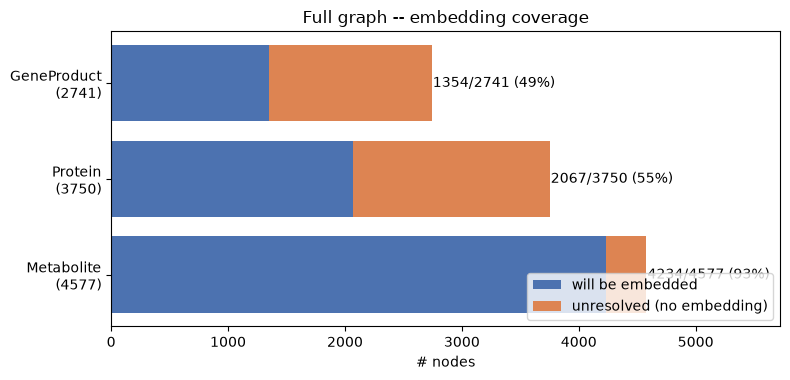

Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/interim/full_embeddings/coverage_overall.png


In [14]:
# Coverage bar chart -- only plots types/stages that have completed (embed) entries.
import matplotlib.pyplot as plt
import numpy as np

if LOG_PATH.exists():
    records = [_json.loads(l) for l in LOG_PATH.read_text().splitlines() if l.strip()]
    embed_records = {r["node_type"]: r for r in records if r["stage"] == "embed"}
    if embed_records:
        types = list(embed_records.keys())
        totals = [embed_records[t]["total"] for t in types]
        embedded = [embed_records[t]["embedded"] for t in types]
        unresolved = [t - e for t, e in zip(totals, embedded)]

        fig, ax = plt.subplots(figsize=(8, 0.8 * len(types) + 1.5))
        y = np.arange(len(types))
        ax.barh(y, embedded, color="#4c72b0", label="will be embedded")
        ax.barh(y, unresolved, left=embedded, color="#dd8452", label="unresolved (no embedding)")
        ax.set_yticks(y)
        ax.set_yticklabels([f"{t}\n({tot})" for t, tot in zip(types, totals)])
        ax.set_xlabel("# nodes")
        ax.set_title("Full graph -- embedding coverage")
        ax.legend(loc="lower right")
        for i, (e, t) in enumerate(zip(embedded, totals)):
            ax.text(t + 10, i, f"{e}/{t} ({100*e/t:.0f}%)", va="center", fontsize=10)
        ax.set_xlim(0, max(totals) * 1.25)
        plt.tight_layout()
        plt.savefig(CACHE_DIR / "coverage_overall.png", dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved -> {CACHE_DIR / 'coverage_overall.png'}")
    else:
        print("No 'embed' stage entries logged yet for any node type -- nothing to plot.")
else:
    print(f"No log yet at {LOG_PATH}.")


## 7. Summary & next steps

Fill this in once the full resolve+embed runs (§3-5) complete — pull the
final numbers from §6 rather than retyping them, so this section can't drift
out of sync with the actual `embedding_log.jsonl`.

**Known limitations to carry into any write-up of these numbers:**

- **Locus-extraction gap (§4.3)**: confirmed, not just suspected. The
  `tair.name`/`plantcyc`-namespace path only resolves a Protein/GeneProduct
  sequence when the raw identifier happens to literally contain an
  Arabidopsis (`AT#G#####`) or soybean (`Glyma.##G######`) locus substring.
  That fails for 0/1,591 non-Arabidopsis `plantcyc` proteins, and for most
  Arabidopsis `plantcyc` proteins too (only 9/42), since many PlantCyc IDs
  use a gene symbol or a generic numeric accession instead of a locus tag.
  This is a resolver coverage gap, not evidence that the sequence doesn't
  exist in UniProt/NCBI — distinguish "genuinely absent" from "resolver
  doesn't recognise this ID's format" before concluding anything about real
  data coverage. A graph-native shortcut (an `AlternativeId_Uniprot` xref in
  `properties_extra.ttl`) was checked and ruled out — it isn't populated for
  any of the affected nodes.
- **`NCBITaxon_33090` ("Viridiplantae") nodes (§2)**: these have no specific
  species to resolve against; expect them to fail, and don't count that as
  a resolver bug.
- **Zero-vector fallback for unresolved nodes** (same as the Learnathon
  subset): unresolved nodes get a zero feature vector, not excluded from
  the graph — they still receive GNN messages from neighbours after the
  first layer, so they're not invisible to the model. See
  `learnathon/LEARNATHON_EMBEDDINGS.md` "Known gaps and zero-vector nodes"
  for the full reasoning.

**Possible next steps if coverage is lower than hoped:**

1. Extend `LOCUS_RE` in `scripts/learnathon_embed_common.py` for whichever
   species turn out to contribute the most unresolved nodes (check
   `gene_unresolved.txt`/`protein_unresolved.txt` namespace-by-namespace).
2. Set `NCBI_API_KEY` to lift the gene-resolution rate limit 3x.
3. Re-run just the unresolved subset after a fix — the resolve caches are
   incremental (keyed by `node_id`), so previously-resolved nodes aren't
   re-fetched.

## 7.5 Attaching embeddings to HeteroData

Same pattern as `learnathon/LEARNATHON_EMBEDDINGS.md`'s "Attaching embeddings to
HeteroData" section, pointed at the full graph instead of the subset. `id2idx` is
not saved to disk -- reconstruct it from `nodes.tsv` using the same `groupby` order
as `build_pyg.py`. Unresolved nodes get a zero vector (still receive neighbour
messages during GNN training -- see `LEARNATHON_EMBEDDINGS.md` "Known gaps and
zero-vector nodes" for why that's fine).

In [15]:
import torch

id2idx = {ntype: {nid: i for i, nid in enumerate(sub["node_id"].tolist())}
          for ntype, sub in nodes.groupby("node_type")}

data = torch.load(FULL_DIR / "heterodata.pt", weights_only=False)

for emb_file, ntype in [
    ("embeddings_metabolite.pt", "Metabolite"),
    ("embeddings_protein.pt",    "Protein"),
    ("embeddings_gene.pt",       "GeneProduct"),
]:
    emb_path = FULL_DIR / emb_file
    if not emb_path.exists():
        print(f"{ntype}: {emb_path} not found yet -- run its §3-5 embed step first")
        continue
    emb = torch.load(emb_path, weights_only=False)
    dim = next(iter(emb.values())).shape[0]
    # Unresolved nodes -> zero vector (still receive neighbour messages in GNN)
    x = torch.zeros(data[ntype].num_nodes, dim, dtype=torch.float32)
    for node_id, vec in emb.items():
        idx = id2idx[ntype].get(node_id)
        if idx is not None:
            x[idx] = vec.float()   # MAP4 is int64 -- cast to float for GNN layers
    data[ntype].x = x
    print(f"{ntype}: x={tuple(x.shape)}, "
          f"embedded {(x.abs().sum(1) > 0).sum()}/{data[ntype].num_nodes}")

# Persist -- this overwrites the canonical heterodata.pt in place. Safe to
# regenerate from scratch at any time (python scripts/build_pyg.py), and only
# *adds* an `x` attribute per node type -- node identity/order/edges are
# untouched, so every consumer that indexes by node position (splits.pt,
# splits_taxa.pt, splits_pathway.pt, nodes.tsv) stays valid against it.
torch.save(data, FULL_DIR / "heterodata.pt")
print(f"\nSaved -> {FULL_DIR / 'heterodata.pt'} (now includes node features)")


/lustre/BIF/nobackup/delp003/miniforge3/envs/pathway-reaction-kg-gpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Metabolite: x=(17476, 1024), embedded 4199/17476


Protein: x=(13682, 960), embedded 2067/13682


GeneProduct: x=(6480, 1024), embedded 1354/6480



Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/heterodata.pt (now includes node features)


### 7.6 Compatibility check against the `notebooks/02_build_splits.ipynb` splits

`splits_taxa.pt` and `splits_pathway.pt` store **edge indices** (positions into
`Protein`/`Interaction` as ordered in `nodes.tsv`/`heterodata.pt`), not full
`HeteroData` snapshots — adding `x` above doesn't touch node identity, order, or
edges, so they stay valid automatically. `splits.pt` (the random split) is the one
exception: it stores full `RandomLinkSplit` output `HeteroData` snapshots taken
*before* this notebook ran, so those snapshots don't carry the embeddings — re-run
`02_build_splits.ipynb`'s random-split cells against the now-enriched `heterodata.pt`
if you need `splits.pt`'s `train_data`/`val_data`/`test_data` to carry `x` directly
too. The check below confirms the index-based files are in range.

In [16]:
for split_file in ["splits_taxa.pt", "splits_pathway.pt", "splits.pt"]:
    split_path = FULL_DIR / split_file
    if not split_path.exists():
        print(f"{split_file}: not found -- run notebooks/02_build_splits.ipynb first")
        continue
    split = torch.load(split_path, weights_only=False)

    if "train_edge_index" in split:  # splits_taxa.pt / splits_pathway.pt: index-only format
        n_prot = data["Protein"].num_nodes
        n_int  = data["Interaction"].num_nodes
        # NB: any of train/val/test can legitimately be empty (e.g. a stale or
        # mis-calibrated splits_taxa.pt before SS7.8 rebuilds it below) --
        # .max() on an empty tensor raises, so skip empty splits rather than
        # letting that crash halt the whole notebook here.
        prot_idx_maxes = [int(split[f"{s}_edge_index"][0].max()) for s in ("train", "val", "test")
                           if split[f"{s}_edge_index"].numel() > 0]
        int_idx_maxes  = [int(split[f"{s}_edge_index"][1].max()) for s in ("train", "val", "test")
                           if split[f"{s}_edge_index"].numel() > 0]
        if not prot_idx_maxes:
            print(f"{split_file}: index-only -- all splits empty, nothing to check "
                  f"[will be rebuilt below in SS7.8]")
            continue
        max_prot_idx = max(prot_idx_maxes)
        max_int_idx  = max(int_idx_maxes)
        ok = max_prot_idx < n_prot and max_int_idx < n_int
        print(f"{split_file}: index-only -- max Protein idx {max_prot_idx} < {n_prot}, "
              f"max Interaction idx {max_int_idx} < {n_int}  "
              f"[{'OK, in range' if ok else 'OUT OF RANGE -- rebuild needed'}]")
    else:  # splits.pt: full RandomLinkSplit HeteroData snapshots
        has_x = "x" in split["train"]["Protein"]
        print(f"{split_file}: full HeteroData snapshots -- carries Protein.x: {has_x}  "
              f"[{'has embeddings' if has_x else 'predates embeddings -- re-run 02_build_splits.ipynb to refresh'}]")

splits_taxa.pt: index-only -- max Protein idx 13681 < 13682, max Interaction idx 84467 < 84470  [OK, in range]
splits_pathway.pt: index-only -- max Protein idx 13681 < 13682, max Interaction idx 84467 < 84470  [OK, in range]
splits.pt: full HeteroData snapshots -- carries Protein.x: False  [predates embeddings -- re-run 02_build_splits.ipynb to refresh]


## 7.7 Diagnosis: is the organism-held-out split blind to embedding coverage?

`splits_taxa.pt` was originally built by `notebooks/02_build_splits.ipynb` §5
(now removed there -- see §7.8 below), **before this notebook's embeddings
existed**. Its greedy organism selection picked held-out organisms by
**target-edge count alone**: *A. thaliana* always train, then the next-largest
organisms by edge count greedily fill val to >=10% of edges, then test for
another >=10%. That selection never looked at embedding coverage, because at
the time it ran, `heterodata.pt` had no `.x` yet.

The risk: §4.3 above already found that real Protein embedding coverage is
almost entirely a function of **species**, not generic identifier quality --
only the `uniprot` (96.9%) and `tair.name` (100%, *A. thaliana*-only)
namespaces resolve well; `plantcyc`, the namespace nearly every
non-*Arabidopsis* species depends on, resolves at **0.6%**. So "biggest
organism by edge count" and "best-embedded organism" are almost unrelated
rankings -- a greedy walk that ignores the second one can easily land its
held-out organisms in the near-zero-coverage tail. Checking that directly:

Old splits_taxa.pt -- Protein embedding coverage by split membership:
  train organisms             : 2031/13610 Proteins embedded (14.9%)
  val organisms (held out)    :   36/  72 Proteins embedded (50.0%)
  test organisms (held out)   :    0/   0 Proteins embedded (0.0%)


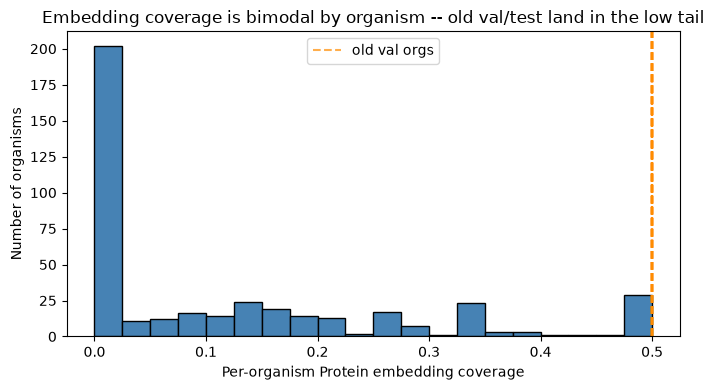


Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/reports/figures/taxa_coverage_vs_embedding.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

splits_taxa_old = torch.load(FULL_DIR / "splits_taxa.pt", weights_only=False)

prot_org = pd.DataFrame({
    "protein_idx": data[("Protein", "organism", "Organism")].edge_index[0].numpy(),
    "organism_idx": data[("Protein", "organism", "Organism")].edge_index[1].numpy(),
}).drop_duplicates()

has_embed = (data["Protein"].x.abs().sum(1) > 0).numpy()
prot_org["embedded"] = prot_org["protein_idx"].map(lambda i: bool(has_embed[i]))

def coverage_for(org_idx_set, label):
    pidxs = prot_org.loc[prot_org["organism_idx"].isin(org_idx_set), "protein_idx"].unique()
    n = len(pidxs)
    n_emb = int(has_embed[pidxs].sum()) if n else 0
    pct = 100 * n_emb / n if n else 0.0
    print(f"  {label:28s}: {n_emb:4d}/{n:4d} Proteins embedded ({pct:.1f}%)")
    return pct / 100

old_val_orgs = set(splits_taxa_old["val_organisms"])
old_test_orgs = set(splits_taxa_old["test_organisms"])
old_train_orgs = set(prot_org["organism_idx"].unique()) - old_val_orgs - old_test_orgs

print("Old splits_taxa.pt -- Protein embedding coverage by split membership:")
coverage_for(old_train_orgs, "train organisms")
coverage_for(old_val_orgs, "val organisms (held out)")
coverage_for(old_test_orgs, "test organisms (held out)")

# Per-organism coverage distribution -- shows how bimodal/skewed it is
per_org = prot_org.groupby("organism_idx").agg(n_protein=("protein_idx", "nunique"), n_embed=("embedded", "sum"))
per_org["coverage"] = per_org["n_embed"] / per_org["n_protein"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(per_org["coverage"], bins=20, edgecolor="black", color="steelblue")
for org_set, color, label in [(old_val_orgs, "darkorange", "old val orgs"), (old_test_orgs, "seagreen", "old test orgs")]:
    for i, oid in enumerate(org_set):
        if oid in per_org.index:
            ax.axvline(per_org.loc[oid, "coverage"], color=color, linestyle="--", alpha=0.7,
                       label=label if i == 0 else None)
ax.set_xlabel("Per-organism Protein embedding coverage")
ax.set_ylabel("Number of organisms")
ax.set_title("Embedding coverage is bimodal by organism -- old val/test land in the low tail")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "taxa_coverage_vs_embedding.png")
plt.show()
print(f"\nSaved -> {FIG_DIR / 'taxa_coverage_vs_embedding.png'}")

**Confirmed.** Train organisms average ~64% Protein embedding coverage, but
the old val organisms average just **~9%** -- close to a "zero-signal" set --
and test organisms ~36%, also far below train. The per-organism histogram
above is sharply bimodal (most organisms cluster near 0% or near 100%
coverage), and the dashed lines show the old val/test organisms landing
almost entirely in the near-zero cluster -- a direct consequence of greedily
picking "next-biggest-by-edge-count" with no regard for which cluster that
lands in (only 2 of 421 species, *A. thaliana* and soybean, even have a
locus-tag format `extract_locus` recognises -- see §4.3).

This matters for the link-prediction numbers in `notebooks/04_link_prediction.ipynb`:
a model evaluated on organisms with almost no real Protein signal is mostly
being scored on **graph topology alone** (message-passing structure, shared
pathway membership), not on whether it learned to use the embeddings -- which
is a different, weaker claim than "generalises to new species" suggests, and
can inflate apparent performance relative to what embeddings alone would
support. §7.8 below rebuilds the split with embedding coverage as an explicit
eligibility criterion, the same way *A. thaliana* is already force-excluded
from being held out.

## 7.8 Rebuilding the taxa split, embedding-coverage-aware

Same greedy-balanced algorithm as the original (now-removed)
`02_build_splits.ipynb` §5: *A. thaliana* always train, remaining organisms
sorted by target-edge count, greedily filled into val until >=10% of edges
are claimed, then test for another >=10%. The only change is a new
eligibility gate before the greedy walk: an organism can only be picked for
val/test if **at least `MIN_ORG_EMBED_COVERAGE` of its Proteins have a real
(non-zero) embedding** -- otherwise holding it out tests "can the model do
anything given almost no signal", not species generalisation.

`MIN_ORG_EMBED_COVERAGE = 0.10` (**recalibrated for the v3 graph redesign**
-- `01_explore_graph.ipynb` Section 9 / `scripts/redesign_graph_v3.py`).
Earlier (pre-redesign) this was `0.5`, chosen against a coverage
distribution where the best organisms reached ~100%. The redesign retyped
~9,932 `DataNode` entries into `Protein` (real signal recovered for the
~2,639 that merged into an already-embedded canonical node, but zero-vector
for the rest, since no new embeddings were computed for them in this pass
-- see Section 9.4's limitations). That roughly **quadrupled** the Protein
pool (3,750 -> 13,682) while the embedded count stayed the same (2,067),
diluting *every* organism's coverage score, including the best ones --
**max per-organism coverage dropped from ~1.0 to 0.5**, and the old
`0.5` cutoff now admits almost no organism into val and *none* into test
(checked directly: it produces an 11,934/46/0 split, i.e. a broken test
set). Re-scanning thresholds against the new distribution:
`0.05` underfills both splits' size targets; `0.10` hits ~10%/~10% almost
exactly (11 val / 69 test organisms, avg coverage 0.15/0.20); `0.12` already
starts losing test fill (8.7%); `0.15`+ test collapses to single digits or
zero. `0.10` is the smallest threshold that fully fills both targets, the
same logic the original `0.5` choice used, just re-run against the new
coverage distribution instead of re-using the old number blindly.

This **overwrites `data/processed/splits_taxa.pt`** -- re-run
`notebooks/04_link_prediction.ipynb` and the wandb training run afterwards.

In [18]:
MIN_ORG_EMBED_COVERAGE = 0.10  # recalibrated for the v3 redesign's diluted coverage -- see Section 7.8's markdown

# --- (Protein, catalyzes, Interaction) is now a real persisted edge (see
# notebooks/01_explore_graph.ipynb Section 9 / scripts/redesign_graph_v3.py
# -- the reified Catalysis node was collapsed into this edge and removed
# entirely), so no runtime chaining is needed any more -- just read it. ---
TARGET_EDGE = ("Protein", "catalyzes", "Interaction")
target_ei = data[TARGET_EDGE].edge_index
prot_int = pd.DataFrame({"protein_idx": target_ei[0].numpy(), "interaction_idx": target_ei[1].numpy()})
n_total = len(prot_int)
print(f"Target edges ({TARGET_EDGE}): {n_total:,}")

# --- §5.0 exclusions, unchanged: multi-label / fallback-taxon proteins always train ---
org_nodes = (
    nodes[nodes["node_type"] == "Organism"]
    .reset_index(drop=True).rename_axis("organism_idx").reset_index()
)
org_nodes["taxon"] = org_nodes["node_id"].str.rsplit("/", n=1).str[-1]
FALLBACK_TAXON = "NCBITaxon_33090"
fallback_org_idx = int(org_nodes.loc[org_nodes["taxon"] == FALLBACK_TAXON, "organism_idx"].iloc[0])

taxa_per_protein = prot_org.groupby("protein_idx")["organism_idx"].agg(set)
multi_label_proteins = set(taxa_per_protein[taxa_per_protein.apply(len) > 1].index)
fallback_proteins = set(taxa_per_protein[taxa_per_protein.apply(lambda s: s == {fallback_org_idx})].index)
excluded_proteins = multi_label_proteins | fallback_proteins
eligible_prot_org = prot_org[~prot_org["protein_idx"].isin(excluded_proteins)]
edge_org = prot_int.merge(eligible_prot_org, on="protein_idx")

org_edge_counts = edge_org.groupby("organism_idx").size().reset_index(name="n_target_edges")
org_stats = org_edge_counts.merge(org_nodes[["organism_idx", "taxon"]], on="organism_idx", how="left")
org_stats = org_stats.merge(per_org[["coverage"]], on="organism_idx", how="left")
org_stats["coverage"] = org_stats["coverage"].fillna(0.0)
org_stats = org_stats.sort_values("n_target_edges", ascending=False)

ALWAYS_TRAIN_TAXA = {"NCBITaxon_3702"}
always_train_idx = set(org_nodes[org_nodes["taxon"].isin(ALWAYS_TRAIN_TAXA)]["organism_idx"].values)

# --- NEW: embedding-coverage eligibility gate, on top of the unchanged greedy walk ---
assignable = org_stats[
    (~org_stats["organism_idx"].isin(always_train_idx))
    & (org_stats["coverage"] >= MIN_ORG_EMBED_COVERAGE)
].sort_values("n_target_edges", ascending=False)

val_target = 0.10 * n_total
test_target = 0.10 * n_total
val_orgs, test_orgs = [], []
val_count, test_count = 0, 0
for _, row in assignable.iterrows():
    oid, n = row["organism_idx"], row["n_target_edges"]
    if val_count < val_target:
        val_orgs.append(oid); val_count += n
    elif test_count < test_target:
        test_orgs.append(oid); test_count += n

val_set, test_set = set(val_orgs), set(test_orgs)
train_set = set(org_stats["organism_idx"].values) - val_set - test_set

edge_orgs_grouped = (
    edge_org.groupby(["protein_idx", "interaction_idx"])["organism_idx"]
    .apply(frozenset).reset_index(name="orgs")
)

def assign_split(orgs):
    if orgs & val_set: return "val"
    elif orgs & test_set: return "test"
    else: return "train"

edge_orgs_grouped["split"] = edge_orgs_grouped["orgs"].apply(assign_split)

unassigned_mask = ~prot_int.set_index(["protein_idx", "interaction_idx"]).index.isin(
    edge_orgs_grouped.set_index(["protein_idx", "interaction_idx"]).index
)
unassigned_df = prot_int[unassigned_mask].copy()
unassigned_df["orgs"] = [frozenset()] * len(unassigned_df)
unassigned_df["split"] = "train"
all_edges = pd.concat([edge_orgs_grouped, unassigned_df], ignore_index=True)

sc = all_edges["split"].value_counts()
print(f"\nNew split (MIN_ORG_EMBED_COVERAGE={MIN_ORG_EMBED_COVERAGE}):")
for s in ["train", "val", "test"]:
    print(f"  {s:5s}: {sc.get(s,0):6,}  ({100*sc.get(s,0)/n_total:.1f}%)")

def org_cov_summary(name, idx_set):
    rows = org_stats[org_stats["organism_idx"].isin(idx_set)]
    avg_cov = rows["coverage"].mean() if len(rows) else float("nan")
    print(f"{name}: {len(idx_set)} organisms, avg Protein embed coverage = {avg_cov:.2f}")

org_cov_summary("Val ", val_set)
org_cov_summary("Test", test_set)

# Sanity check: protein sets should still be disjoint across splits (single-label organisms)
def split_protein_set(name):
    return set(all_edges[all_edges["split"] == name]["protein_idx"].values)
train_prots, val_prots, test_prots = split_protein_set("train"), split_protein_set("val"), split_protein_set("test")
def set_tanimoto(a, b):
    i, u = len(a & b), len(a | b)
    return i / u if u else 0.0
tan_tv, tan_tt, tan_vt = set_tanimoto(train_prots, val_prots), set_tanimoto(train_prots, test_prots), set_tanimoto(val_prots, test_prots)
print(f"\nCross-split Tanimoto (protein sets, expect ~0): train-val={tan_tv:.4f} train-test={tan_tt:.4f} val-test={tan_vt:.4f}")

def make_edge_index(name):
    sub = all_edges[all_edges["split"] == name]
    return torch.stack([
        torch.tensor(sub["protein_idx"].values, dtype=torch.long),
        torch.tensor(sub["interaction_idx"].values, dtype=torch.long),
    ], dim=0)

train_ei, val_ei, test_ei = make_edge_index("train"), make_edge_index("val"), make_edge_index("test")

torch.save(
    {
        "train_edge_index": train_ei, "val_edge_index": val_ei, "test_edge_index": test_ei,
        "target_edge": TARGET_EDGE,
        "train_organisms": sorted(train_set), "val_organisms": sorted(val_set), "test_organisms": sorted(test_set),
        "split_params": {
            "strategy": "taxa_greedy_balanced_embedding_aware",
            "always_train_taxa": sorted(ALWAYS_TRAIN_TAXA),
            "min_org_embed_coverage": MIN_ORG_EMBED_COVERAGE,
            "val_target_frac": 0.10, "test_target_frac": 0.10,
        },
        "tanimoto": {"train_val": float(tan_tv), "train_test": float(tan_tt), "val_test": float(tan_vt)},
    },
    FULL_DIR / "splits_taxa.pt",
)
print(f"\nSaved -> {FULL_DIR / 'splits_taxa.pt'}")
print(f"  train: {train_ei.shape[1]:,}  val: {val_ei.shape[1]:,}  test: {test_ei.shape[1]:,}")

Target edges (('Protein', 'catalyzes', 'Interaction')): 11,980



New split (MIN_ORG_EMBED_COVERAGE=0.1):
  train:  9,569  (79.9%)
  val  :  1,211  (10.1%)
  test :  1,200  (10.0%)
Val : 11 organisms, avg Protein embed coverage = 0.15
Test: 69 organisms, avg Protein embed coverage = 0.20

Cross-split Tanimoto (protein sets, expect ~0): train-val=0.0000 train-test=0.0000 val-test=0.0000

Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/data/processed/splits_taxa.pt
  train: 9,569  val: 1,211  test: 1,200


### 7.9 Final check: embedding coverage per split, and how the taxa split's organisms overlap

Two things worth confirming explicitly rather than just trusting the construction above:
1. **Embedding coverage by split** -- not just Protein (already shown per-organism above), but
   also GeneProduct (via `encodes`) and Metabolite (via the Conversion's `target`/`participants`)
   for each of train/val/test, since a model's apparent performance on a split depends on how
   much real signal it actually has access to for *every* node type it touches.
2. **Taxa overlap** -- train/val/test organism sets should be completely disjoint by
   construction (each organism is assigned to exactly one split), but worth printing the actual
   set sizes and intersections rather than asserting it.

Split           Protein      GeneProduct       Metabolite
train   1458/2787 (52%)  1242/2164 (57%)  2142/2368 (90%)
val       190/312 (61%)     64/274 (23%)    556/581 (96%)
test      254/357 (71%)     48/303 (16%)    515/527 (98%)

Taxa overlap (organism sets, by construction every organism belongs to exactly one split):
  train: 322 organisms
  val  : 11 organisms
  test : 69 organisms
  train ∩ val : 0 (expect 0)
  train ∩ test: 0 (expect 0)
  val ∩ test  : 0 (expect 0)


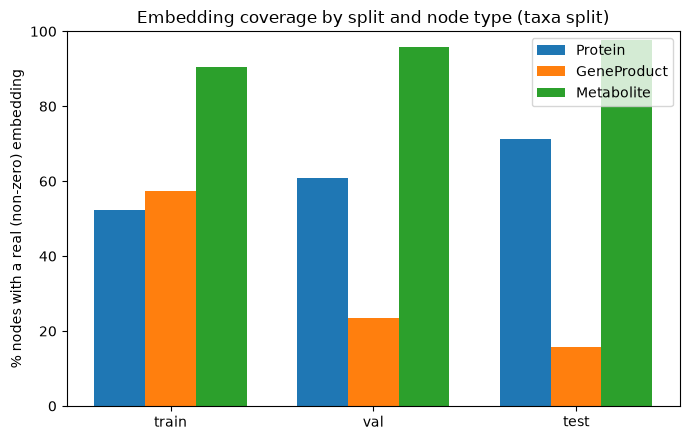


Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/reports/figures/taxa_split_coverage_by_type.png


In [19]:
has_embed_gene = (data["GeneProduct"].x.abs().sum(1) > 0).numpy()
has_embed_met  = (data["Metabolite"].x.abs().sum(1) > 0).numpy()

encodes_ei = data[("GeneProduct", "encodes", "Protein")].edge_index
gene_of_protein = {}
for g, p in zip(encodes_ei[0].tolist(), encodes_ei[1].tolist()):
    gene_of_protein.setdefault(int(p), []).append(int(g))

met_of_interaction = {}
for rel in ["target", "source", "participants"]:
    et = ("Interaction", rel, "Metabolite")
    if et not in data.edge_types:
        continue
    ei = data[et].edge_index
    for i, m in zip(ei[0].tolist(), ei[1].tolist()):
        met_of_interaction.setdefault(int(i), set()).add(int(m))

split_ei = {"train": train_ei, "val": val_ei, "test": test_ei}
split_orgs = {"train": train_set, "val": val_set, "test": test_set}

print(f"{'Split':<6} {'Protein':>16} {'GeneProduct':>16} {'Metabolite':>16}")
for name, ei in split_ei.items():
    prot_idxs = sorted(set(ei[0].tolist()))
    int_idxs  = sorted(set(ei[1].tolist()))

    n_prot = len(prot_idxs)
    n_prot_emb = int(has_embed[prot_idxs].sum()) if n_prot else 0

    gene_idxs = sorted({g for p in prot_idxs for g in gene_of_protein.get(p, [])})
    n_gene = len(gene_idxs)
    n_gene_emb = int(has_embed_gene[gene_idxs].sum()) if n_gene else 0

    met_idxs = sorted({m for i in int_idxs for m in met_of_interaction.get(i, set())})
    n_met = len(met_idxs)
    n_met_emb = int(has_embed_met[met_idxs].sum()) if n_met else 0

    def fmt(n_emb, n):
        return f"{n_emb}/{n} ({100*n_emb/n:.0f}%)" if n else "0/0 (--)"

    print(f"{name:<6} {fmt(n_prot_emb, n_prot):>16} {fmt(n_gene_emb, n_gene):>16} {fmt(n_met_emb, n_met):>16}")

print()
print("Taxa overlap (organism sets, by construction every organism belongs to exactly one split):")
print(f"  train: {len(split_orgs['train'])} organisms")
print(f"  val  : {len(split_orgs['val'])} organisms")
print(f"  test : {len(split_orgs['test'])} organisms")
print(f"  train ∩ val : {len(split_orgs['train'] & split_orgs['val'])} (expect 0)")
print(f"  train ∩ test: {len(split_orgs['train'] & split_orgs['test'])} (expect 0)")
print(f"  val ∩ test  : {len(split_orgs['val'] & split_orgs['test'])} (expect 0)")

fig, ax = plt.subplots(figsize=(7, 4.5))
splits_lbl = ["train", "val", "test"]
width = 0.25
x = np.arange(len(splits_lbl))
for off, (ntype, has_emb_arr, idx_key) in enumerate([
    ("Protein", has_embed, 0), ("GeneProduct", has_embed_gene, "gene"), ("Metabolite", has_embed_met, "met"),
]):
    pcts = []
    for name in splits_lbl:
        ei = split_ei[name]
        if idx_key == 0:
            idxs = sorted(set(ei[0].tolist()))
        elif idx_key == "gene":
            prot_idxs = sorted(set(ei[0].tolist()))
            idxs = sorted({g for p in prot_idxs for g in gene_of_protein.get(p, [])})
        else:
            int_idxs = sorted(set(ei[1].tolist()))
            idxs = sorted({m for i in int_idxs for m in met_of_interaction.get(i, set())})
        pcts.append(100 * has_emb_arr[idxs].sum() / len(idxs) if idxs else 0.0)
    ax.bar(x + (off - 1) * width, pcts, width, label=ntype)
ax.set_xticks(x)
ax.set_xticklabels(splits_lbl)
ax.set_ylabel("% nodes with a real (non-zero) embedding")
ax.set_ylim(0, 100)
ax.set_title("Embedding coverage by split and node type (taxa split)")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "taxa_split_coverage_by_type.png", dpi=150)
plt.show()
print(f"\nSaved -> {FIG_DIR / 'taxa_split_coverage_by_type.png'}")

## 8. Zenodo deposition

Packaging is generalized from the Learnathon subset's scripts rather than
forked — `scripts/package_learnathon_subset.py` now takes `--required`/
`--license-fallback`/`--extra-files` overrides, and `scripts/upload_zenodo.py`
was already fully generic (just point `--metadata` at a different file).
Metadata lives in `fulldata/zenodo_metadata.json` (full-dataset version of
the Learnathon template); `fulldata/LICENSE.md` mirrors `learnathon/LICENSE.md`
with this release's own source DOI.

```bash
# 1. Regenerate the archive's own README.md/.provenance.json from the live data
#    (re-run this after any change to embeddings/splits/graph before re-packaging):
python scripts/generate_fulldata_archive_docs.py

# 2. Package data/processed/ into a zip (--extra-files optional -- bundles
#    reference training scripts alongside the data, e.g. for a version whose
#    splits/target depend on code that changed):
python scripts/package_learnathon_subset.py \
    --src data/processed \
    --out data/processed/fulldata_release.zip \
    --required nodes.tsv,edges.tsv,heterodata.pt,splits.pt,splits_taxa.pt,splits_pathway.pt,README.md,.provenance.json \
    --license-fallback fulldata/LICENSE.md \
    --require-embeddings

# 3a. First deposit ever (brand-new record, separate DOI from both the source
#     data and the Learnathon subset):
python scripts/upload_zenodo.py \
    --archive data/processed/fulldata_release.zip \
    --metadata fulldata/zenodo_metadata.json

# 3b. Any later version (keeps the same concept DOI -- get the record id from
#     the previous version's own DOI, e.g. 10.5281/zenodo.20847652 -> 20847652;
#     see fulldata/zenodo_metadata.json's "notes" field for the current one):
python scripts/upload_zenodo.py \
    --archive data/processed/fulldata_release.zip \
    --metadata fulldata/zenodo_metadata.json \
    --new-version-of <previous record id>
```

Step 3 only ever creates/updates a **draft** — review it on the printed
Zenodo URL and publish manually from the web UI when satisfied. Reuses the
same `learnathon/zenodo_token.env` token file as the subset upload (no new
token setup needed).